# Plan your trip

In [9]:
import os
import pandas as pd
from warnings import filterwarnings
filterwarnings("ignore")
from IPython.display import Image

# Local application

from scripts.rds_sql import base_sql
from scripts.cartes import visualiser_cartes_dataset_final
os.makedirs("data", exist_ok=True)

## 1 - Géocodage des villes

In [10]:
# Exécution du script geocode_ville.py
%run scripts/geocodage_villes.py

# Visualiser les données géocodées
df_geo = pd.read_csv("data/geocode_villes.csv")
display(df_geo.head())
print(f"{len(df_geo)} villes géocodées.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\geocode_villes.csv


,id_ville,ville,latitude,longitude
0,fb1372c111d5,Mont Saint Michel,48.635954,-1.511460
1,b1926dc4d399,Saint Malo,48.649518,-2.026041
2,5fd0187b51b2,Bayeux,49.276462,-0.702474
3,4e9b8cad09f6,Le Havre,49.493898,0.107973
4,e76e9773c33d,Rouen,49.440459,1.093966


35 villes géocodées.


## 2 - Données météo

In [11]:
# Exécution du script complet meteo.py
%run scripts/meteo.py

df_meteo = pd.read_csv("data/villes_meteo.csv")
display(df_meteo.head())
print(f"Données météo récupérées pour {len(df_meteo)} villes.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\villes_meteo.csv


,id_ville,nom_ville,temp_moy,ressenti,humidity_moy,prob_pluie_moy,uv_moy,meteo_score
0,794f211090be,Chateau du Haut Koenigsbourg,6.6,6.2,73.6,20.0,0.8,43.2
1,bb29bb72d5fe,Strasbourg,7.9,6.5,72.7,20.0,0.7,39.0
2,b33bc6c3bd6e,Eguisheim,8.8,8.1,72.3,40.0,0.8,38.3
3,83b47b11c640,Colmar,9.0,8.3,72.7,40.0,0.8,38.2
4,4cc9af0bda9a,Collioure,15.1,14.7,77.7,580.0,0.9,32.1


Données météo récupérées pour 35 villes.


## 3 - Hotels

In [12]:
# Exécution du script complet scrape_hotels.py
%run scripts/meteo.py

df_hotels = pd.read_csv("data/hotels.csv")
display(df_hotels.head(10))
print(f"{len(df_hotels)} hôtels récupérés.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\villes_meteo.csv


,id,id_ville,ville,nom,url,note,latitude,longitude
0,e10874a5-ddc7-4d41-b8d6-ab30b8bf5b69,fb1372c111d5,Mont Saint Michel,Les Terrasses Poulard,https://www.booking.com/hotel/fr/les-terrasses...,"Avec une note de 7,4\n7,4\nBien \n3 605 expéri...",48.635954,-1.511460
1,a10f8229-08d7-4ae5-a6ae-0d3f8bf60f69,fb1372c111d5,Mont Saint Michel,Mercure Mont Saint Michel,https://www.booking.com/hotel/fr/mont-saint-mi...,"Avec une note de 8,3\n8,3\nTrès bien\n3 668 ex...",48.635954,-1.511460
2,55afa455-22b3-4ecb-8c36-bef12bc7ac67,fb1372c111d5,Mont Saint Michel,La Mère Poulard,https://www.booking.com/hotel/fr/la-mere-poula...,"Avec une note de 7,6\n7,6\nBien \n3 380 expéri...",48.635954,-1.511460
3,f61016a1-6e4f-408e-8e81-d8b0c28356c6,fb1372c111d5,Mont Saint Michel,Hotel Gabriel,https://www.booking.com/hotel/fr/hotel-gabriel...,"Avec une note de 8,3\n8,3\nTrès bien\n2 568 ex...",48.635954,-1.511460
4,fdb57245-b8f3-4af3-8678-95d54230fe3f,fb1372c111d5,Mont Saint Michel,Le Relais Saint Michel,https://www.booking.com/hotel/fr/le-relais-sai...,"Avec une note de 8,3\n8,3\nTrès bien\n4 262 ex...",48.635954,-1.511460
5,1e895dcc-45e9-4781-97af-ac402f6e70a7,b1926dc4d399,Saint Malo,Les Bois Flottés,https://www.booking.com/hotel/fr/les-bois-flot...,"Avec une note de 9,1\n9,1\nFabuleux \n100 expé...",48.649518,-2.026041
6,9b21af24-b574-44e4-86fe-e8517759502c,b1926dc4d399,Saint Malo,T2 terrasse de charme à Rochebonne 400 m plage,https://www.booking.com/hotel/fr/t2-de-charme-...,"Avec une note de 9,5\n9,5\nExceptionnel\n70 ex...",48.649518,-2.026041
7,3295d08e-c835-44a7-9087-8b603d161920,b1926dc4d399,Saint Malo,Kyriad Prestige Saint-Malo,https://www.booking.com/hotel/fr/kyriad-presti...,"Avec une note de 8,8\n8,8\nSuperbe\n6 253 expé...",48.649518,-2.026041
8,533c1b88-bbf4-4f52-b65f-41a253c42ec8,b1926dc4d399,Saint Malo,Bonne rencontre,https://www.booking.com/hotel/fr/bonne-rencont...,"Avec une note de 9,6\n9,6\nExceptionnel\n9 exp...",48.649518,-2.026041
9,d26f4c9f-a711-4fcc-801f-ffbad6b325ea,b1926dc4d399,Saint Malo,Résidence Pierre & Vacances Ty Mat,https://www.booking.com/hotel/fr/maevatymat.fr...,"Avec une note de 8,1\n8,1\nTrès bien\n2 732 ex...",48.649518,-2.026041


175 hôtels récupérés.


## 4 - Fusions et export s3

In [13]:
# Exécution du script complet fusion_chargement_s3.py
%run scripts/fusion_chargement_s3.py

df_final = pd.read_csv("data/dataset_final.csv")
display(df_final.head())
print(f"Shape finale : {df_final.shape}")

Dataset final généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\dataset_final.csv
Colonnes présentes : Index(['id', 'id_ville', 'ville', 'nom', 'url', 'note', 'latitude',
       'longitude', 'nom_ville', 'temp_moy', 'ressenti', 'humidity_moy',
       'prob_pluie_moy', 'uv_moy', 'meteo_score'],
      dtype='object')
                                     id      id_ville              ville  \
0  e10874a5-ddc7-4d41-b8d6-ab30b8bf5b69  fb1372c111d5  Mont Saint Michel   
1  a10f8229-08d7-4ae5-a6ae-0d3f8bf60f69  fb1372c111d5  Mont Saint Michel   
2  55afa455-22b3-4ecb-8c36-bef12bc7ac67  fb1372c111d5  Mont Saint Michel   
3  f61016a1-6e4f-408e-8e81-d8b0c28356c6  fb1372c111d5  Mont Saint Michel   
4  fdb57245-b8f3-4af3-8678-95d54230fe3f  fb1372c111d5  Mont Saint Michel   

                         nom  \
0      Les Terrasses Poulard   
1  Mercure Mont Saint Michel   
2            La Mère Poulard   
3              Hotel Gabriel   
4     Le Relais Saint Mich

,id,id_ville,ville,nom,url,note,latitude,longitude,nom_ville,temp_moy,ressenti,humidity_moy,prob_pluie_moy,uv_moy,meteo_score
0,e10874a5-ddc7-4d41-b8d6-ab30b8bf5b69,fb1372c111d5,Mont Saint Michel,Les Terrasses Poulard,https://www.booking.com/hotel/fr/les-terrasses...,"Avec une note de 7,4\n7,4\nBien \n3 605 expéri...",48.635954,-1.51146,Mont Saint Michel,9.3,7.8,82.3,380.0,0.7,20.7
1,a10f8229-08d7-4ae5-a6ae-0d3f8bf60f69,fb1372c111d5,Mont Saint Michel,Mercure Mont Saint Michel,https://www.booking.com/hotel/fr/mont-saint-mi...,"Avec une note de 8,3\n8,3\nTrès bien\n3 668 ex...",48.635954,-1.51146,Mont Saint Michel,9.3,7.8,82.3,380.0,0.7,20.7
2,55afa455-22b3-4ecb-8c36-bef12bc7ac67,fb1372c111d5,Mont Saint Michel,La Mère Poulard,https://www.booking.com/hotel/fr/la-mere-poula...,"Avec une note de 7,6\n7,6\nBien \n3 380 expéri...",48.635954,-1.51146,Mont Saint Michel,9.3,7.8,82.3,380.0,0.7,20.7
3,f61016a1-6e4f-408e-8e81-d8b0c28356c6,fb1372c111d5,Mont Saint Michel,Hotel Gabriel,https://www.booking.com/hotel/fr/hotel-gabriel...,"Avec une note de 8,3\n8,3\nTrès bien\n2 568 ex...",48.635954,-1.51146,Mont Saint Michel,9.3,7.8,82.3,380.0,0.7,20.7
4,fdb57245-b8f3-4af3-8678-95d54230fe3f,fb1372c111d5,Mont Saint Michel,Le Relais Saint Michel,https://www.booking.com/hotel/fr/le-relais-sai...,"Avec une note de 8,3\n8,3\nTrès bien\n4 262 ex...",48.635954,-1.51146,Mont Saint Michel,9.3,7.8,82.3,380.0,0.7,20.7


Shape finale : (175, 15)


## 5 - Chargement SQL/RDS

In [14]:
# Exécution du script complet rds_sql.py
%run scripts/rds_sql.py

base_sql()
print("Chargement terminé !")

Données insérées avec succès dans RDS.
Données insérées avec succès dans RDS.
Chargement terminé !


## 6 - Génération des cartes

Connecté à RDS
Connexion RDS fermée


Top villes exportées : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.png, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.html, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.csv


Top hôtels exportés : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.png, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.html, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.csv
Connecté à RDS
Connexion RDS fermée


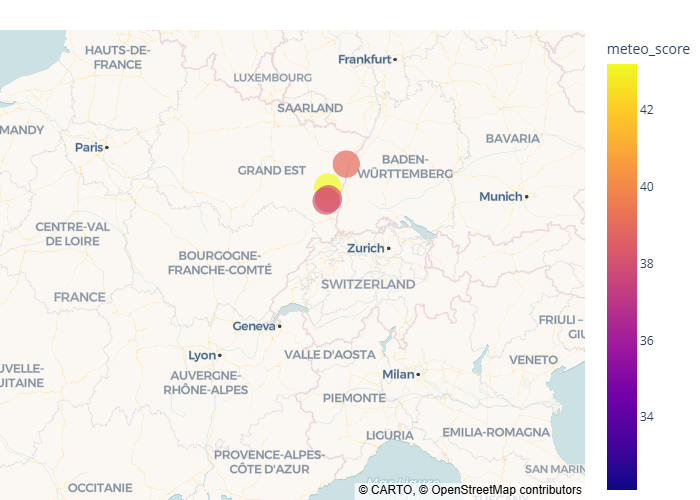

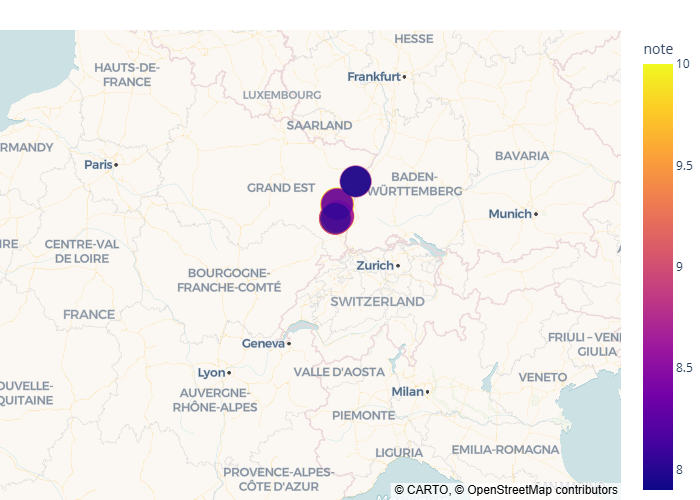

In [15]:
# Exécution du script complet cartes.py
%run scripts/cartes.py

visualiser_cartes_dataset_final(top_villes=5, top_hotels=20, save_files=False)
# Chemin vers ton PNG
png_path_1 = "data/top_villes.png"
png_path_2 = "data/top_hotels.png"

# Affichage dans le notebook
display(Image(filename=png_path_1))
display(Image(filename=png_path_2))